# [APP] Application — ShiftMetrics Executive Dashboard

**Layer:** Gold (read-only consumption)
**Author:** ShiftMetrics Analytics — EAFIT SI7006 Trabajo 3
**Audience:** Engineering Managers · Product Owners · CTO

## Purpose
This notebook is the **application layer** of the medallion architecture. It consumes
the curated `gold` schema exclusively and produces executive-ready visualizations
and recommendations for **Shift-Left Testing adoption**.

No raw transformations happen here — only consumption of stable, business-grade KPIs.

## Sections
1. Executive summary (single-page metrics)
2. Defect-prone projects ranking + ML risk overlay
3. Model performance dashboard (ROC + confusion matrix + feature importance)
4. Red Hat process health (cycle time + throughput)
5. Cross-domain insights (PROMISE <-> Red Hat via dim_project)
6. **Actionable recommendations** for SLT adoption
7. Architecture and deliverables index

In [0]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd
from pyspark.sql import functions as F
from pyspark.sql.types import DecimalType, DoubleType
from sklearn.metrics import roc_curve, precision_recall_curve, auc

GOLD = "workspace.shiftmetrics_gold"

# Reproducible plot style — executive presentation grade
mpl.rcParams.update({
    "figure.dpi":           120,
    "savefig.dpi":           120,
    "savefig.bbox":          "tight",
    "font.family":           "DejaVu Sans",
    "font.size":             10,
    "axes.titlesize":        13,
    "axes.titleweight":      "bold",
    "axes.labelsize":        11,
    "axes.spines.top":       False,
    "axes.spines.right":     False,
    "axes.grid":             True,
    "grid.alpha":            0.25,
    "legend.frameon":        False,
})
sns.set_palette("deep")

def to_pandas_numeric(sdf):
    """Cast DecimalType columns to DoubleType before .toPandas()."""
    decimal_cols = [f.name for f in sdf.schema.fields if isinstance(f.dataType, DecimalType)]
    for c in decimal_cols:
        sdf = sdf.withColumn(c, F.col(c).cast(DoubleType()))
    return sdf.toPandas()

print(f"  matplotlib: {mpl.__version__}")
print(f"  seaborn:    {sns.__version__}")
print(f"  spark:      {spark.version}")
print(f"  gold schema: {GOLD}")

  matplotlib: 3.7.2
  seaborn:    0.12.2
  spark:      4.1.0
  gold schema: workspace.shiftmetrics_gold


## [1] Executive summary — single-page metrics

In [0]:
# Pull headline numbers from gold
defect_summary = to_pandas_numeric(
    spark.sql(f"""
        SELECT
            SUM(modules)           AS total_modules,
            SUM(buggy_modules)     AS total_buggy,
            ROUND(100.0 * SUM(buggy_modules) / SUM(modules), 1) AS overall_pct_buggy,
            COUNT(*)               AS n_projects
        FROM {GOLD}.kpi_defect_distribution_by_project
    """)
).iloc[0]

throughput_summary = to_pandas_numeric(
    spark.sql(f"""
        SELECT
            SUM(issues_created)    AS total_issues,
            SUM(issues_resolved)   AS total_resolved,
            MIN(year)              AS first_year,
            MAX(year)              AS last_year,
            ROUND(AVG(avg_cycle_days), 1) AS avg_cycle_days_overall
        FROM {GOLD}.kpi_throughput_yearly
    """)
).iloc[0]

ml_summary = to_pandas_numeric(
    spark.sql(f"""
        SELECT model_name, framework,
               ROUND(auc_test, 4)  AS auc_test,
               ROUND(f1_test, 4)   AS f1_test,
               ROUND(precision_test, 4) AS precision_w,
               ROUND(recall_test, 4)    AS recall_w
        FROM {GOLD}.ml_model_metrics
        WHERE is_champion = 'True'
        ORDER BY run_ts DESC
        LIMIT 1
    """)
).iloc[0]

# Render as a clean executive panel
print("\n" + "[*] SHIFTMETRICS — EXECUTIVE SUMMARY")
print(f"\n  [CODE] CODE QUALITY (PROMISE — Apache projects)")
print(f"      Projects analyzed:        {int(defect_summary['n_projects']):>10}")
print(f"      Modules analyzed:         {int(defect_summary['total_modules']):>10,}")
print(f"      Buggy modules:            {int(defect_summary['total_buggy']):>10,}")
print(f"      Overall defect rate:      {float(defect_summary['overall_pct_buggy']):>9.1f}%")

print(f"\n  [PROCESS] PROCESS METRICS (Red Hat — Jira PBIs)")
print(f"      Period:                   {int(throughput_summary['first_year'])}–{int(throughput_summary['last_year'])}")
print(f"      Issues created:           {int(throughput_summary['total_issues']):>10,}")
print(f"      Issues resolved:          {int(throughput_summary['total_resolved']):>10,}")
print(f"      Avg cycle time (overall): {float(throughput_summary['avg_cycle_days_overall']):>9.1f}d")

print(f"\n  [ML] ML CHAMPION MODEL")
print(f"      Model:                    {ml_summary['model_name']}")
print(f"      Framework:                {ml_summary['framework']}")
print(f"      Test AUC:                 {float(ml_summary['auc_test']):>9.4f}")
print(f"      Test F1:                  {float(ml_summary['f1_test']):>9.4f}")
print(f"      Precision (weighted):     {float(ml_summary['precision_w']):>9.4f}")
print(f"      Recall (weighted):        {float(ml_summary['recall_w']):>9.4f}")
print("[*]")


[*] SHIFTMETRICS — EXECUTIVE SUMMARY

  [CODE] CODE QUALITY (PROMISE — Apache projects)
      Projects analyzed:                11
      Modules analyzed:             15,775
      Buggy modules:                 5,728
      Overall defect rate:           36.3%

  [PROCESS] PROCESS METRICS (Red Hat — Jira PBIs)
      Period:                   2010–2024
      Issues created:              472,562
      Issues resolved:             405,258
      Avg cycle time (overall):     178.8d

  [ML] ML CHAMPION MODEL
      Model:                    RandomForest (sklearn)
      Framework:                sklearn
      Test AUC:                    0.7316
      Test F1:                     0.6869
      Precision (weighted):        0.7010
      Recall (weighted):           0.7112
[*]


## [2] Defect-prone projects ranking — Where to focus SLT first

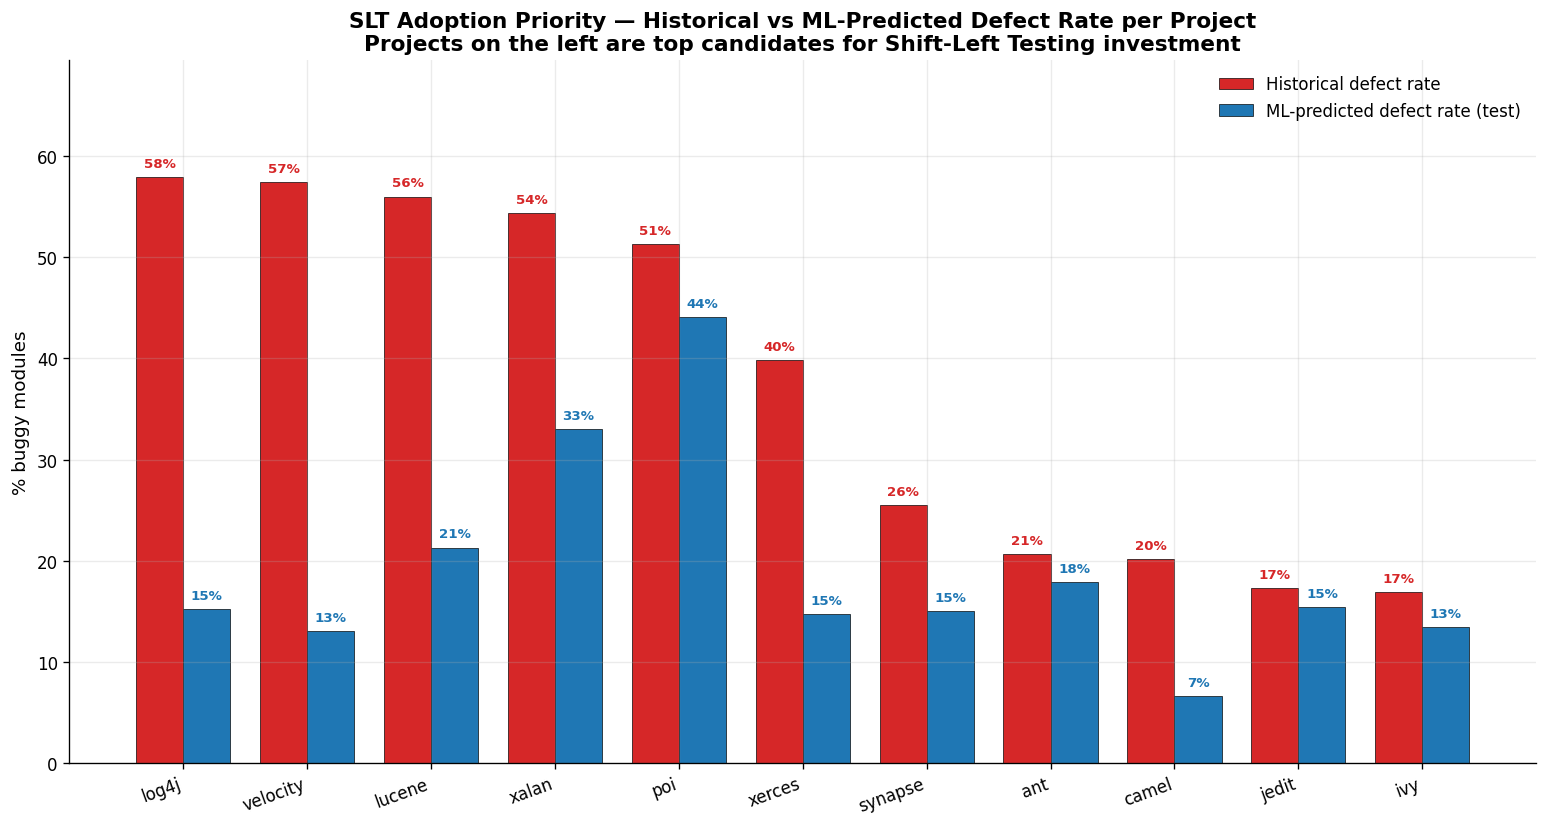

project,modules,buggy_modules,pct_buggy,avg_bug_density,avg_loc,n_test_modules,avg_predicted_risk,pct_predicted_buggy
log4j,449,260,57.91,0.06066,177.5,92,0.3365,15.2
velocity,639,367,57.43,0.04968,253.3,138,0.3282,13.0
lucene,782,438,56.01,0.02768,277.5,150,0.3816,21.3
xalan,3320,1806,54.4,0.01958,412.7,612,0.4524,33.0
poi,1378,707,51.31,0.00892,288.6,286,0.4579,44.1
xerces,1643,654,39.81,0.05752,339.8,333,0.3249,14.7
synapse,635,162,25.51,0.00707,196.2,120,0.316,15.0
ant,1692,350,20.69,0.00211,296.0,329,0.3315,17.9
camel,2784,562,20.19,0.01673,111.8,562,0.2707,6.6
jedit,1749,303,17.32,0.00253,457.3,345,0.3352,15.4


In [0]:
# Combine defect distribution with ML predictions per project
defect_pdf = to_pandas_numeric(
    spark.sql(f"""
        SELECT d.project,
               d.modules,
               d.buggy_modules,
               d.pct_buggy,
               d.avg_bug_density,
               d.avg_loc
        FROM {GOLD}.kpi_defect_distribution_by_project d
        ORDER BY d.pct_buggy DESC
    """)
)

# Get ML risk score per project from predictions table
ml_risk_pdf = to_pandas_numeric(
    spark.sql(f"""
        SELECT project,
               COUNT(*)                                     AS n_test_modules,
               ROUND(AVG(prob_buggy), 4)                    AS avg_predicted_risk,
               ROUND(100.0 * AVG(prediction), 1)            AS pct_predicted_buggy
        FROM {GOLD}.ml_predictions
        GROUP BY project
        ORDER BY avg_predicted_risk DESC
    """)
)

merged = defect_pdf.merge(ml_risk_pdf, on="project", how="left").sort_values("pct_buggy", ascending=False)

fig, ax = plt.subplots(figsize=(13, 7))
x = np.arange(len(merged))
width = 0.38

bar1 = ax.bar(x - width/2, merged["pct_buggy"], width,
              label="Historical defect rate",
              color="#d62728", edgecolor="black", linewidth=0.4)
bar2 = ax.bar(x + width/2, merged["pct_predicted_buggy"], width,
              label="ML-predicted defect rate (test)",
              color="#1f77b4", edgecolor="black", linewidth=0.4)

# Value labels on top
for b, v in zip(bar1, merged["pct_buggy"]):
    ax.text(b.get_x() + b.get_width()/2, v + 1, f"{float(v):.0f}%",
            ha="center", fontsize=8, color="#d62728", fontweight="bold")
for b, v in zip(bar2, merged["pct_predicted_buggy"]):
    if not np.isnan(v):
        ax.text(b.get_x() + b.get_width()/2, v + 1, f"{float(v):.0f}%",
                ha="center", fontsize=8, color="#1f77b4", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(merged["project"], rotation=20, ha="right")
ax.set_ylabel("% buggy modules")
ax.set_title("SLT Adoption Priority — Historical vs ML-Predicted Defect Rate per Project\n"
             "Projects on the left are top candidates for Shift-Left Testing investment")
ax.legend(loc="upper right")
ax.set_ylim(0, max(float(merged["pct_buggy"].max()), float(merged["pct_predicted_buggy"].max())) * 1.20)
plt.tight_layout()
plt.show()

# Save the priority table
display(spark.createDataFrame(merged))

## [3] Model performance dashboard
ROC curve + confusion matrix + feature importance, all consumed from gold.

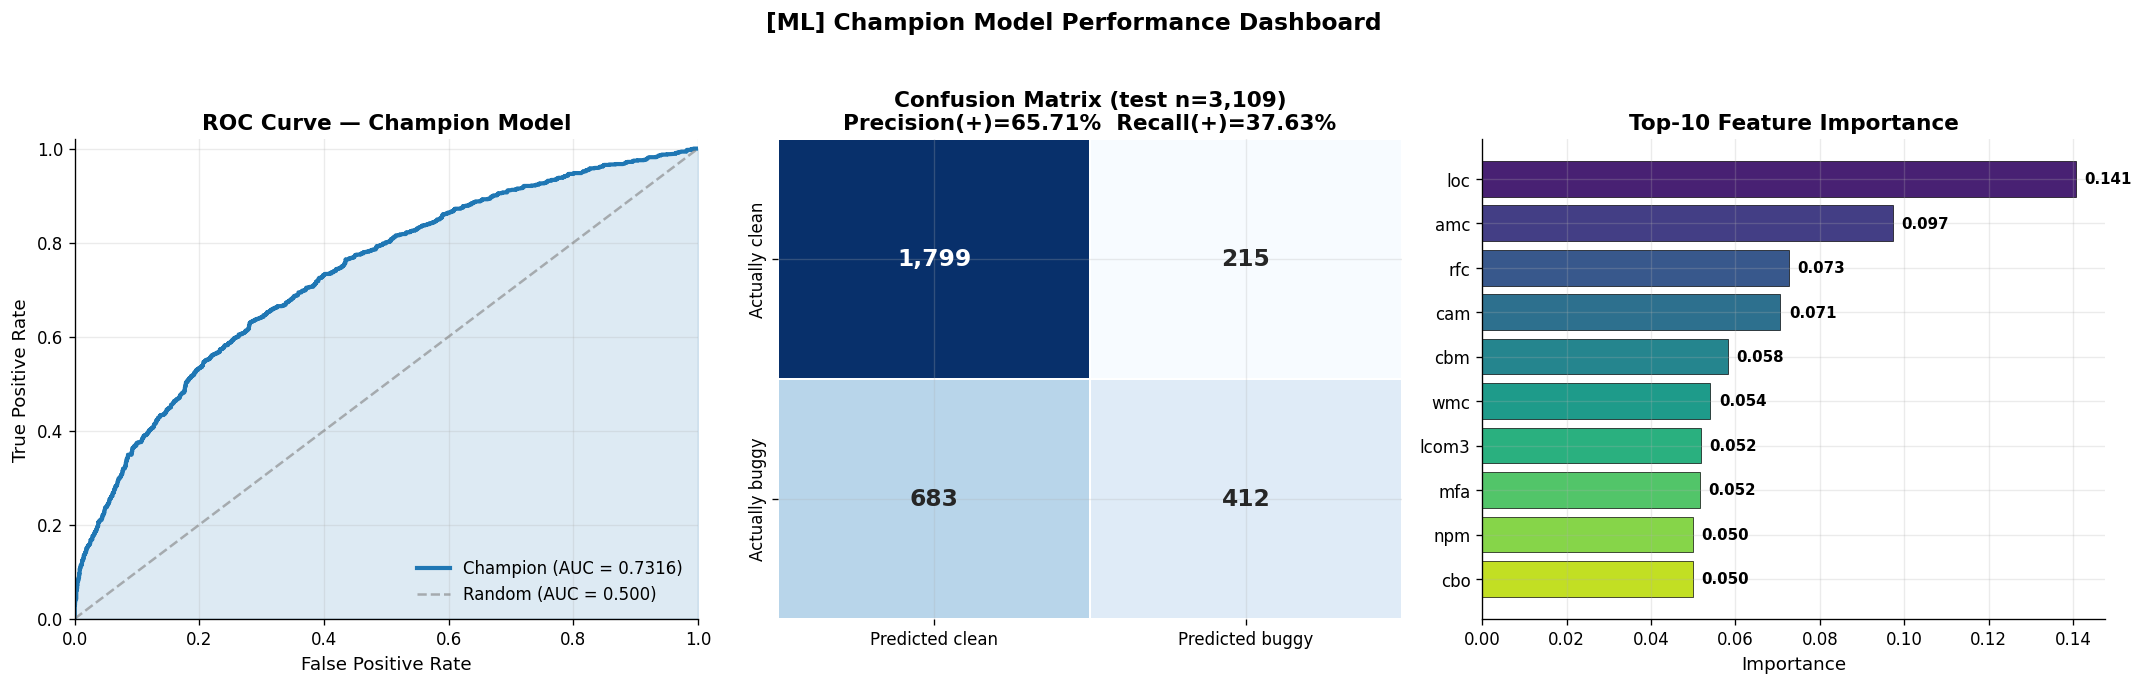

In [0]:
preds_pdf = to_pandas_numeric(
    spark.sql(f"""
        SELECT label, prediction, prob_buggy
        FROM {GOLD}.ml_predictions
    """)
)

cm_pdf = to_pandas_numeric(
    spark.sql(f"""
        SELECT cell, count
        FROM {GOLD}.ml_confusion_matrix
        WHERE run_ts = (SELECT MAX(run_ts) FROM {GOLD}.ml_confusion_matrix)
        ORDER BY cell
    """)
).set_index("cell")["count"]

fi_pdf = to_pandas_numeric(
    spark.sql(f"""
        SELECT feature, importance, rank
        FROM {GOLD}.ml_feature_importance
        WHERE run_ts = (SELECT MAX(run_ts) FROM {GOLD}.ml_feature_importance)
        ORDER BY rank
    """)
)

# Build 3-panel dashboard
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# ── Panel 1: ROC curve ──────────────────────────────────────────────────────
ax = axes[0]
fpr, tpr, _ = roc_curve(preds_pdf["label"].values, preds_pdf["prob_buggy"].values)
auc_val = auc(fpr, tpr)
ax.plot(fpr, tpr, color="#1f77b4", linewidth=2.5, label=f"Champion (AUC = {auc_val:.4f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", alpha=0.6, label="Random (AUC = 0.500)")
ax.fill_between(fpr, tpr, alpha=0.15, color="#1f77b4")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Champion Model")
ax.legend(loc="lower right")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

# ── Panel 2: Confusion matrix heatmap ───────────────────────────────────────
ax = axes[1]
tp = int(cm_pdf.get("TP", 0)); fp = int(cm_pdf.get("FP", 0))
tn = int(cm_pdf.get("TN", 0)); fn = int(cm_pdf.get("FN", 0))
cm_matrix = np.array([[tn, fp], [fn, tp]])
sns.heatmap(cm_matrix, annot=True, fmt=",", cmap="Blues", cbar=False,
            xticklabels=["Predicted clean", "Predicted buggy"],
            yticklabels=["Actually clean", "Actually buggy"],
            ax=ax, linewidths=1, linecolor="white",
            annot_kws={"size": 14, "weight": "bold"})

# Precision/recall annotations
prec_pos = tp / (tp + fp) if (tp + fp) > 0 else 0
rec_pos  = tp / (tp + fn) if (tp + fn) > 0 else 0
ax.set_title(f"Confusion Matrix (test n={tp+fp+tn+fn:,})\nPrecision(+)={prec_pos:.2%}  Recall(+)={rec_pos:.2%}")

# ── Panel 3: Feature importance (top 10) ────────────────────────────────────
ax = axes[2]
top10 = fi_pdf.head(10).iloc[::-1]
bars = ax.barh(top10["feature"], top10["importance"],
               color=sns.color_palette("viridis_r", n_colors=10),
               edgecolor="black", linewidth=0.4)
for b, v in zip(bars, top10["importance"]):
    ax.text(float(v) + 0.002, b.get_y() + b.get_height()/2,
            f"{float(v):.3f}", va="center", fontsize=9, fontweight="bold")
ax.set_title("Top-10 Feature Importance")
ax.set_xlabel("Importance")

fig.suptitle("[ML] Champion Model Performance Dashboard",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

## [4] Red Hat process health — Cycle time and throughput evolution

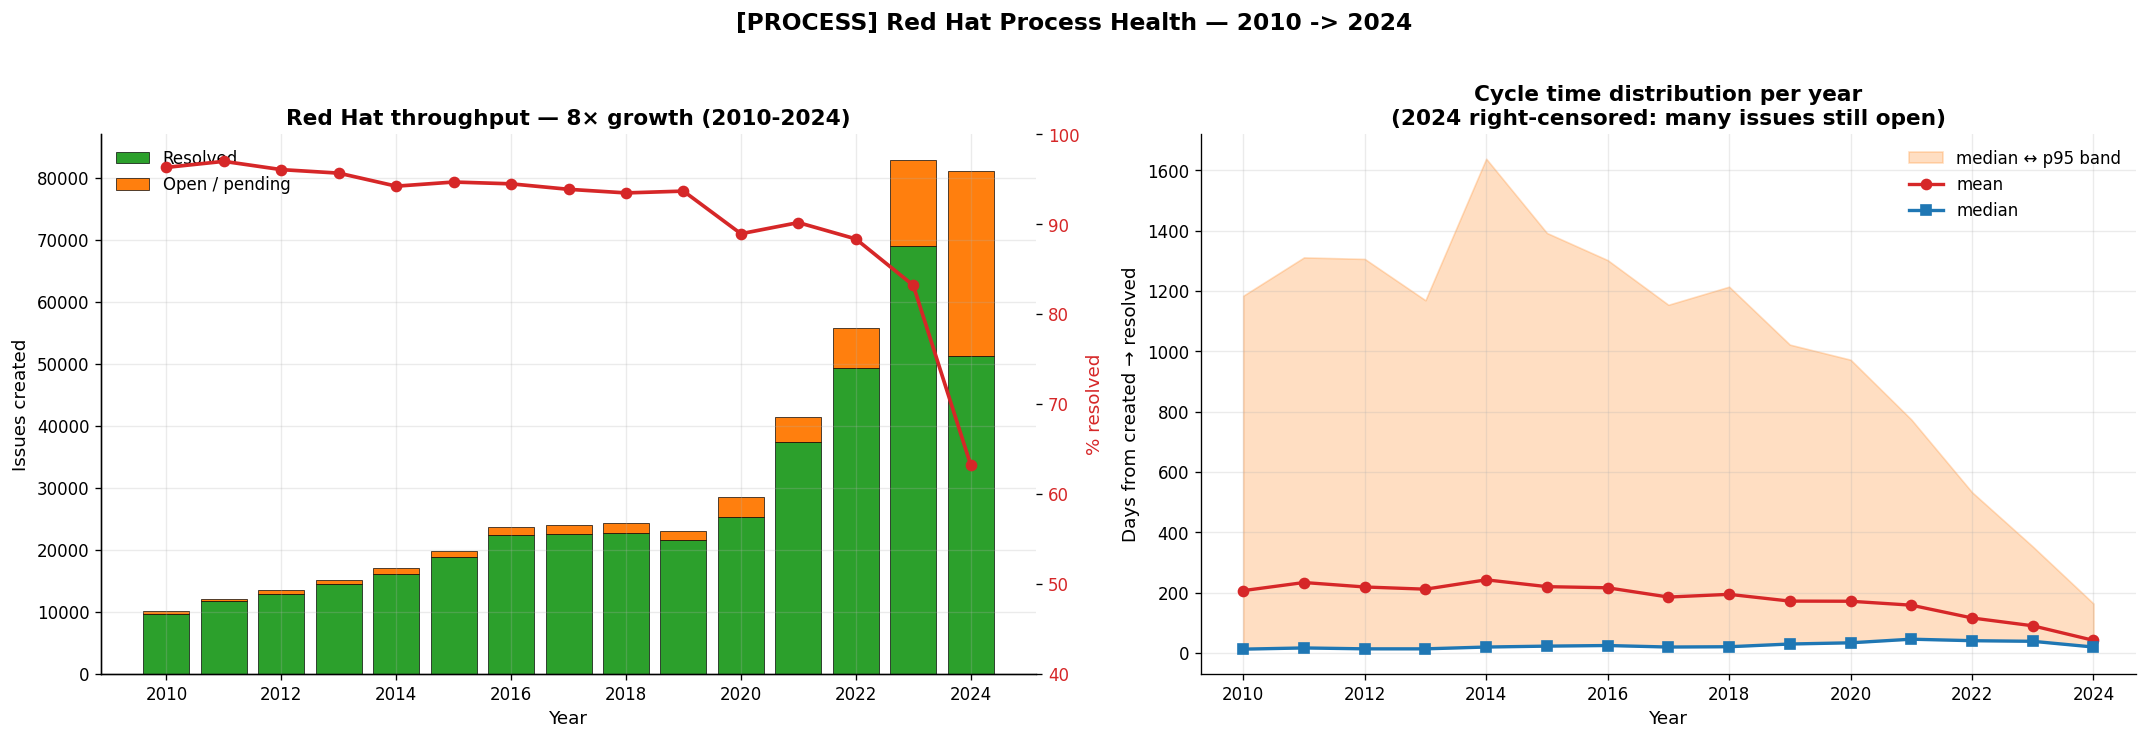

In [0]:
thr_pdf = to_pandas_numeric(spark.table(f"{GOLD}.kpi_throughput_yearly"))

# 2-panel: throughput + resolution rate + cycle time evolution
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Panel 1: Throughput evolution ───────────────────────────────────────────
ax = axes[0]
ax.bar(thr_pdf["year"], thr_pdf["issues_resolved"],
       color="#2ca02c", edgecolor="black", linewidth=0.4, label="Resolved")
ax.bar(thr_pdf["year"], thr_pdf["issues_created"] - thr_pdf["issues_resolved"],
       bottom=thr_pdf["issues_resolved"],
       color="#ff7f0e", edgecolor="black", linewidth=0.4, label="Open / pending")
ax.set_xlabel("Year")
ax.set_ylabel("Issues created")
ax.set_title("Red Hat throughput — 8× growth (2010-2024)")
ax.legend(loc="upper left")

ax2 = ax.twinx()
ax2.plot(thr_pdf["year"], thr_pdf["pct_resolved"], color="#d62728",
         marker="o", linewidth=2.2, label="% resolved")
ax2.set_ylabel("% resolved", color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")
ax2.set_ylim(40, 100)
ax2.grid(False)

# ── Panel 2: Cycle time evolution ───────────────────────────────────────────
ax = axes[1]
ax.fill_between(thr_pdf["year"],
                thr_pdf["median_cycle_days"],
                thr_pdf["p95_cycle_days"],
                alpha=0.25, color="#ff7f0e", label="median ↔ p95 band")
ax.plot(thr_pdf["year"], thr_pdf["avg_cycle_days"], marker="o",
        linewidth=2, color="#d62728", label="mean")
ax.plot(thr_pdf["year"], thr_pdf["median_cycle_days"], marker="s",
        linewidth=2, color="#1f77b4", label="median")
ax.set_xlabel("Year")
ax.set_ylabel("Days from created → resolved")
ax.set_title("Cycle time distribution per year\n(2024 right-censored: many issues still open)")
ax.legend(loc="upper right")

fig.suptitle("[PROCESS] Red Hat Process Health — 2010 -> 2024", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## [5] Cross-domain insights via `dim_project`

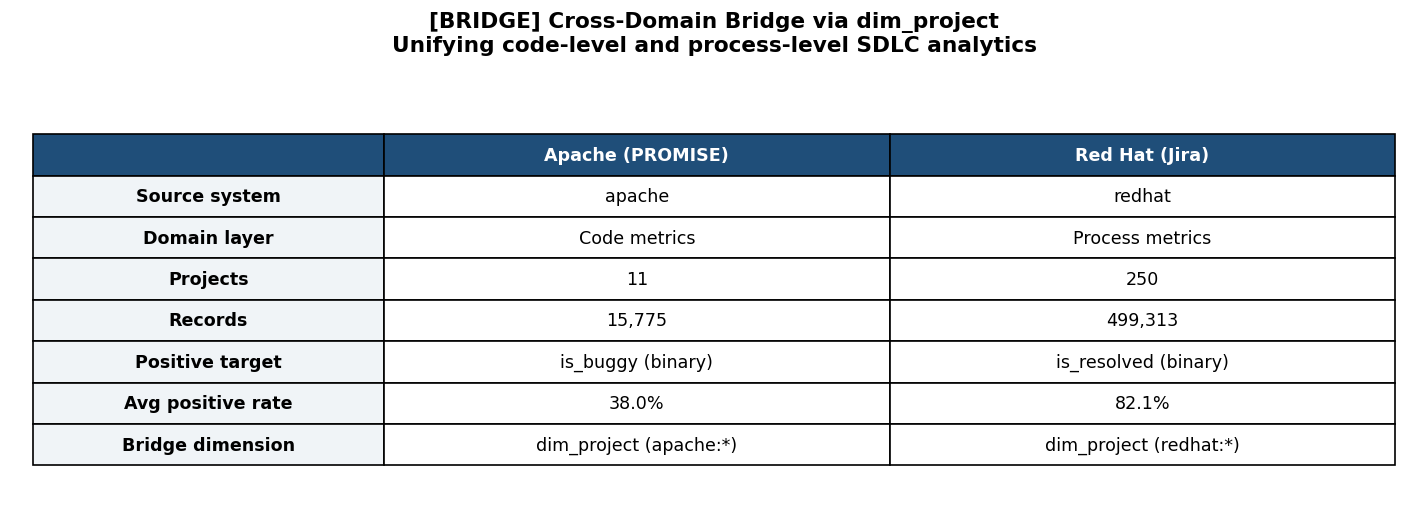

In [0]:
cross_summary = to_pandas_numeric(spark.sql(f"""
    SELECT source_system,
           domain_layer,
           COUNT(*)         AS n_projects,
           SUM(records)     AS total_records,
           ROUND(AVG(positive_rate_pct), 1) AS avg_positive_rate_pct
    FROM {GOLD}.kpi_cross_domain_summary
    GROUP BY source_system, domain_layer
    ORDER BY source_system
"""))

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.axis("off")

# Build a clean comparison "card"
table_data = [
    ["", "Apache (PROMISE)", "Red Hat (Jira)"],
    ["Source system",     "apache",                       "redhat"],
    ["Domain layer",      "Code metrics",                 "Process metrics"],
    ["Projects",          f"{int(cross_summary[cross_summary.source_system=='apache']['n_projects'].iloc[0])}",
                          f"{int(cross_summary[cross_summary.source_system=='redhat']['n_projects'].iloc[0])}"],
    ["Records",           f"{int(cross_summary[cross_summary.source_system=='apache']['total_records'].iloc[0]):,}",
                          f"{int(cross_summary[cross_summary.source_system=='redhat']['total_records'].iloc[0]):,}"],
    ["Positive target",   "is_buggy (binary)",            "is_resolved (binary)"],
    ["Avg positive rate", f"{float(cross_summary[cross_summary.source_system=='apache']['avg_positive_rate_pct'].iloc[0]):.1f}%",
                          f"{float(cross_summary[cross_summary.source_system=='redhat']['avg_positive_rate_pct'].iloc[0]):.1f}%"],
    ["Bridge dimension",  "dim_project (apache:*)",       "dim_project (redhat:*)"],
]

tab = ax.table(cellText=table_data, loc="center", cellLoc="center",
               colWidths=[0.25, 0.36, 0.36])
tab.auto_set_font_size(False)
tab.set_fontsize(10.5)
tab.scale(1, 2.0)

# Format header
for col_idx in range(3):
    cell = tab[0, col_idx]
    cell.set_facecolor("#1f4e79")
    cell.set_text_props(color="white", weight="bold")
for row_idx in range(1, len(table_data)):
    tab[row_idx, 0].set_facecolor("#f0f4f7")
    tab[row_idx, 0].set_text_props(weight="bold")

ax.set_title("[BRIDGE] Cross-Domain Bridge via dim_project\nUnifying code-level and process-level SDLC analytics",
             fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

## [6] Actionable recommendations for SLT adoption

In [0]:
# Build the prioritization scoring: rank projects by combined historical + predicted risk
priority_pdf = to_pandas_numeric(spark.sql(f"""
    WITH defect AS (
        SELECT project, pct_buggy, modules, avg_bug_density
        FROM {GOLD}.kpi_defect_distribution_by_project
    ),
    pred AS (
        SELECT project,
               AVG(prob_buggy)         AS avg_predicted_risk,
               COUNT(*)                AS test_modules
        FROM {GOLD}.ml_predictions
        GROUP BY project
    )
    SELECT d.project,
           d.modules,
           ROUND(d.pct_buggy, 1)              AS pct_buggy_hist,
           ROUND(100 * p.avg_predicted_risk, 1) AS pct_predicted_risk,
           ROUND((d.pct_buggy + 100 * p.avg_predicted_risk) / 2, 1) AS combined_risk_score,
           ROUND(d.avg_bug_density, 4)         AS avg_bug_density
    FROM defect d
    LEFT JOIN pred p ON d.project = p.project
    ORDER BY combined_risk_score DESC
"""))

# Assign priority tiers
def assign_tier(score):
    if score >= 50: return "[P0] CRITICAL"
    if score >= 30: return "[P1] HIGH"
    if score >= 20: return "[P2] MEDIUM"
    return "[P3] LOW"

priority_pdf["slt_priority"] = priority_pdf["combined_risk_score"].apply(assign_tier)

print("[*] SHIFT-LEFT TESTING — PROJECT PRIORITIZATION (combined risk score)")
print(f"  {'Project':<12s} {'Modules':>8s} {'Hist%':>7s} {'Pred%':>7s} {'Score':>7s}  {'Priority':<22s}")
print("  " + "-" * 84)
for _, r in priority_pdf.iterrows():
    print(f"  {r['project']:<12s} {int(r['modules']):>8d} {float(r['pct_buggy_hist']):>6.1f}% "
          f"{float(r['pct_predicted_risk']):>6.1f}% {float(r['combined_risk_score']):>6.1f}  "
          f"{r['slt_priority']:<22s}")
print("[*]")

# Persist as a final actionable table in gold
priority_sdf = spark.createDataFrame(priority_pdf)
(
    priority_sdf.write
        .format("delta")
        .mode("overwrite")
        .option("overwriteSchema", "true")
        .saveAsTable(f"{GOLD}.app_slt_prioritization")
)
spark.sql(f"""
    COMMENT ON TABLE {GOLD}.app_slt_prioritization IS
    'Application-layer output. Combined risk score (historical defect rate + ML-predicted risk) ranking projects for Shift-Left Testing adoption priority. Generated by the application notebook 06_application_dashboard.'
""")

print(f"\n  [OK] Persisted to {GOLD}.app_slt_prioritization for downstream consumption")

[*] SHIFT-LEFT TESTING — PROJECT PRIORITIZATION (combined risk score)
  Project       Modules   Hist%   Pred%   Score  Priority              
  ------------------------------------------------------------------------------------
  xalan            3320   54.4%   45.2%   49.8  [P1] HIGH             
  poi              1378   51.3%   45.8%   48.5  [P1] HIGH             
  lucene            782   56.0%   38.2%   47.1  [P1] HIGH             
  log4j             449   57.9%   33.6%   45.8  [P1] HIGH             
  velocity          639   57.4%   32.8%   45.1  [P1] HIGH             
  xerces           1643   39.8%   32.5%   36.1  [P1] HIGH             
  synapse           635   25.5%   31.6%   28.6  [P2] MEDIUM           
  ant              1692   20.7%   33.1%   26.9  [P2] MEDIUM           
  jedit            1749   17.3%   33.5%   25.4  [P2] MEDIUM           
  ivy               704   16.9%   33.1%   25.0  [P2] MEDIUM           
  camel            2784   20.2%   27.1%   23.6  [P2] MEDIUM  

## [7] Architecture deliverables index

In [0]:
print("═" * 80)
print("  [ASSETS] SHIFTMETRICS LAKEHOUSE — FINAL ASSET INVENTORY")
print("═" * 80)

# Show all tables organized by layer
for schema, layer_name in [
    ("shiftmetrics_bronze",  "[BRONZE] (raw, immutable)"),
    ("shiftmetrics_silver",  "[SILVER] (cleansed, conformed)"),
    ("shiftmetrics_gold",    "[GOLD] (KPIs, ML outputs, app outputs)"),
]:
    print(f"\n  {layer_name}")
    tables = spark.sql(f"""
        SELECT table_name, comment
        FROM workspace.information_schema.tables
        WHERE table_schema = '{schema}' AND table_type = 'MANAGED'
        ORDER BY table_name
    """).collect()
    for t in tables:
        print(f"      - {t['table_name']:<42s} {(t['comment'] or '')[:80]}")

print("\n" + "═" * 80)
print("  [COMPLETE] All deliverables in workspace.shiftmetrics_*")
print("═" * 80)
print(f"\n  [BRONZE]:  2 tables       — immutable source of truth")
print(f"  [SILVER]:  4 tables       — DQ-enforced, deduped, derived columns")
print(f"  [GOLD]:    13 tables      — 8 EDA KPIs + 4 ML outputs + 1 app output")
print(f"\n  [APP]:     app_slt_prioritization -> actionable SLT priorities")
print(f"  [MODELS]:  /Volumes/.../_artifacts/models/champion_<ts>/")

════════════════════════════════════════════════════════════════════════════════
  [ASSETS] SHIFTMETRICS LAKEHOUSE — FINAL ASSET INVENTORY
════════════════════════════════════════════════════════════════════════════════

  [BRONZE] (raw, immutable)
      - code_metrics_raw                           PROMISE defect dataset — C&K + Halstead + McCabe code metrics for 11 Apache proj
      - process_issues_raw                         Red Hat Public Jira PBIs 2001-2024 — process metrics raw. 250 systems × ~490k is

  [SILVER] (cleansed, conformed)
      - _dq_metrics                                Append-only DQ audit log. One row per (run_id, table, check). Used for evidence 
      - code_metrics_clean                         PROMISE clean — deduped on (name,_project,_version), schema-enforced, with deriv
      - dim_project                                Cross-domain bridge dimension. Unifies Apache (PROMISE, code-level) and Red Hat 
      - process_issues_clean                       Red Ha